# Figure 3
Vertical wind shear, 850 hPa vorticity, 600 hPa relative humidity

**P2 (1987-2023) minus P1 (1949-1985)**

**Note:** Processing includes all 10 ensemble members.

Import statements

In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import metpy.calc as mpcalc
import numpy as np
import xarray as xr
from metpy.units import units
from scipy import stats

## List data

In [2]:
start1 = 1949
stop1 = 1985

start2 = 1987
stop21 = 2003
stop22 = 2023

alpha = 0.01

path = "/glade/derecho/scratch/smhenry/neuralGCM/sims/factual-historical/ensmean_JASO/"

name_list_p1 = [
    path + f"{yr}_ensmean_JASO_factual-historical_raw.nc"
    for yr in range(start1, stop1 + 1)
]

name_list_p2_1 = [
    path + f"{yr}_ensmean_JASO_factual-historical_raw.nc"
    for yr in range(start2, stop21 + 1)
]

path = "/glade/work/smhenry/neuralGCM/sims/factual/ensmean_JASO/"

name_list_p2_2 = [
    path + f"{yr}_ensmean_JASO_factual_raw.nc" for yr in range(stop21 + 1, stop22 + 1)
]

## Process data

In [3]:
p1_raw = xr.open_mfdataset(name_list_p1, combine="nested", concat_dim="year")

name_list_p2 = name_list_p2_1 + name_list_p2_2

p2_raw = xr.open_mfdataset(name_list_p2, combine="nested", concat_dim="year")

In [4]:
def compute_diff_and_sig(p1_in, p2_in):
    # Mean difference
    p1_mean = p1_in.mean(dim="year")
    p2_mean = p2_in.mean(dim="year")
    diff = p2_mean - p1_mean

    # Welch's t-test along year dimension
    _, p_val = stats.ttest_ind(
        p2_in.values,
        p1_in.values,
        axis=0,
        equal_var=False,
        nan_policy="omit",
    )

    # Reattach xarray metadata
    mask = xr.DataArray(
        p_val < alpha,
        coords=diff.coords,
        dims=diff.dims,
    )

    return diff, mask

In [5]:
# Helper to compute VWS
def calc_vws(ds):
    u200 = ds.u_component_of_wind.sel(level=200, latitude=slice(-10, 50))
    u850 = ds.u_component_of_wind.sel(level=850, latitude=slice(-10, 50))
    v200 = ds.v_component_of_wind.sel(level=200, latitude=slice(-10, 50))
    v850 = ds.v_component_of_wind.sel(level=850, latitude=slice(-10, 50))
    return np.sqrt((u200 - u850) ** 2 + (v200 - v850) ** 2)


dVWS, VWS_p_mask = compute_diff_and_sig(calc_vws(p1_raw), calc_vws(p2_raw))


# Zeta
def calc_zeta(ds):
    u = ds.u_component_of_wind.sel(level=850, latitude=slice(-10, 50)) * units("m/s")
    v = ds.v_component_of_wind.sel(level=850, latitude=slice(-10, 50)) * units("m/s")
    return mpcalc.vorticity(u, v).metpy.dequantify()


dZeta850, Zeta850_p_mask = compute_diff_and_sig(calc_zeta(p1_raw), calc_zeta(p2_raw))


# Div
def calc_div(ds):
    u = ds.u_component_of_wind.sel(level=850, latitude=slice(-10, 50)) * units("m/s")
    v = ds.v_component_of_wind.sel(level=850, latitude=slice(-10, 50)) * units("m/s")
    return mpcalc.divergence(u, v).metpy.dequantify()


ddiv, div_p_mask = compute_diff_and_sig(calc_div(p1_raw), calc_div(p2_raw))


# RH
def calc_rh(ds):
    t = ds.temperature.sel(level=600, latitude=slice(-10, 50)) * units.K
    q = ds.specific_humidity.sel(level=600, latitude=slice(-10, 50))
    return (
        mpcalc.relative_humidity_from_specific_humidity(
            600 * units.hPa, t, q
        ).metpy.dequantify()
        * 100
    )


dRH600, RH600_p_mask = compute_diff_and_sig(calc_rh(p1_raw), calc_rh(p2_raw))


VWS_p1 = calc_vws(p1_raw).mean("year")
VWS_p2 = calc_vws(p2_raw).mean("year")

Zeta850_p1 = calc_zeta(p1_raw).mean("year")
Zeta850_p2 = calc_zeta(p2_raw).mean("year")

Div850_p1 = calc_div(p1_raw).mean("year")
Div850_p2 = calc_div(p2_raw).mean("year")

RH600_p1 = calc_rh(p1_raw).mean("year")
RH600_p2 = calc_rh(p2_raw).mean("year")

In [6]:
def add_box(ax, lon1, lon2, lat1, lat2):
    ax.plot(
        [lon1, lon2, lon2, lon1, lon1],
        [lat1, lat1, lat2, lat2, lat1],
        color="black", linewidth=1.5, transform=ccrs.PlateCarree(), zorder=5
    )


def plot_decade_data(dat, p, title, ax, levels=None, cmap=None, cbar_shrink=1):
    dat.attrs.pop("units", None)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.set_extent([100, 350, -5, 40], crs=ccrs.PlateCarree())
    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.5,
        color="gray",
        alpha=0.5,
        linestyle="--",
    )
    gl.right_labels = False
    gl.top_labels = False
    dat.plot.contourf(
        x="longitude",
        y="latitude",
        levels=levels,
        robust=True,
        ax=ax,
        transform=ccrs.PlateCarree(),
        extend="both",
        cmap=cmap,
        cbar_kwargs={"shrink": cbar_shrink, "label": ""},
    )
    # Plot significance dots
    if p.size > 1:
        lon2d, lat2d = xr.broadcast(dat.longitude, dat.latitude)
        mask = p.values
        ax.scatter(
            lon2d.values[::2, ::2][mask[::2, ::2]],
            lat2d.values[::2, ::2][mask[::2, ::2]],
            color="black",
            s=2,
            transform=ccrs.PlateCarree(),
            marker=".",
        )
    # MDR boxes
    add_box(ax, 280, 340, 10, 20)   # NA:  20–80W, 10–20N
    add_box(ax, 220, 270, 7.5, 20)  # NEP: 90–140W, 7.5–20N
    add_box(ax, 110, 160, 5, 30)  # NWP: 110–160E, 5–30N
    ax.set_title(title, fontsize=12, pad=5)

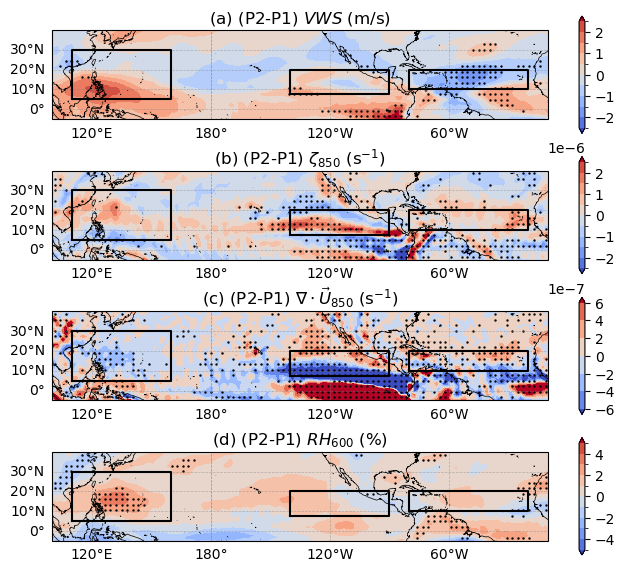

In [7]:
fig, axs = plt.subplots(
    ncols=1,
    nrows=4,
    figsize=(8, 7),
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=180)},
)
axs = axs.flatten()

dat_list = [dVWS, dZeta850, ddiv, dRH600]
pmask_list = [VWS_p_mask, Zeta850_p_mask, div_p_mask, RH600_p_mask]
title_list = [
    r"(a) (P2-P1) $VWS$ (m/s)",
    r"(b) (P2-P1) $\zeta_{850}$ (s$^{-1}$)",
    r"(c) (P2-P1) $\nabla\cdot\vec{U}_{850}$ (s$^{-1}$)",
    r"(d) (P2-P1) $RH_{600}$ (%)",
]
levels = [
    np.arange(-2.5, 3, 0.5),
    np.arange(-2.5e-6, 3e-6, 0.5e-6),
    np.arange(-6e-7, 7e-7, 2e-7),
    np.arange(-5, 6, 1),
]

for i in range(len(axs)):
    plot_decade_data(
        dat_list[i],
        pmask_list[i],
        title_list[i],
        axs[i],
        levels=levels[i],
        cmap="coolwarm",
    )

plt.savefig("./figs/SI_figure_historical-env.png", dpi=600, bbox_inches="tight")
plt.show()

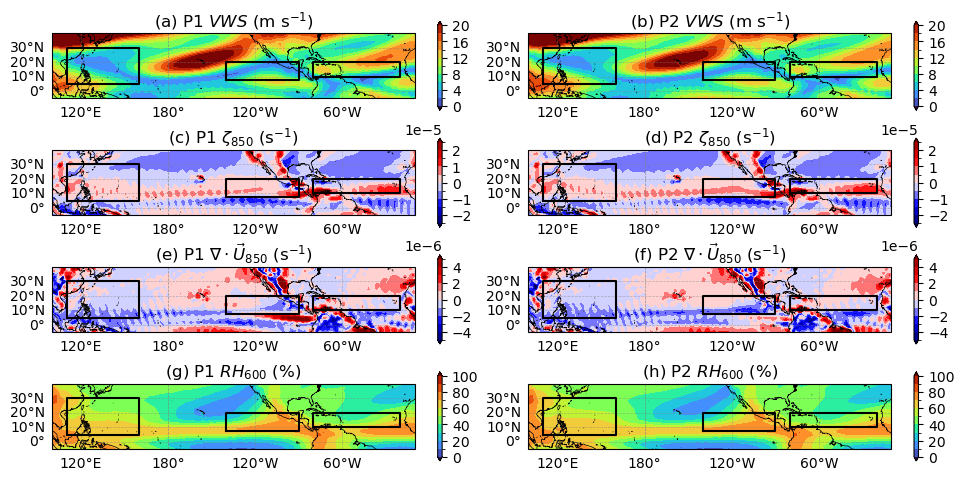

In [8]:
fig, axs = plt.subplots(
    ncols=2,
    nrows=4,
    figsize=(12, 6),
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=180)},
)
axs = axs.flatten()

lev_VWS = np.arange(0, 20 + 2, 2)
lev_zeta = np.arange(-2.5e-5, 2.5e-5 + 2.5e-5 / 5, 2.5e-5 / 5)
lev_div = np.arange(-5e-6, 5e-6 + 5e-6 / 5, 5e-6 / 5)
lev_rh = np.arange(0, 100 + 100 / 10, 100 / 10)

dat_list = [
    VWS_p1,
    VWS_p2,
    Zeta850_p1,
    Zeta850_p2,
    Div850_p1,
    Div850_p2,
    RH600_p1,
    RH600_p2,
]
pmask_list = [
    xr.DataArray(np.array([np.nan])),
    xr.DataArray(np.array([np.nan])),
    xr.DataArray(np.array([np.nan])),
    xr.DataArray(np.array([np.nan])),
    xr.DataArray(np.array([np.nan])),
    xr.DataArray(np.array([np.nan])),
    xr.DataArray(np.array([np.nan])),
    xr.DataArray(np.array([np.nan])),
]
title_list = [
    r"(a) P1 $VWS$ (m s$^{-1}$)",
    r"(b) P2 $VWS$ (m s$^{-1}$)",
    r"(c) P1 $\zeta_{850}$ (s$^{-1}$)",
    r"(d) P2 $\zeta_{850}$ (s$^{-1}$)",
    r"(e) P1 $\nabla\cdot\vec{U}_{850}$ (s$^{-1}$)",
    r"(f) P2 $\nabla\cdot\vec{U}_{850}$ (s$^{-1}$)",
    r"(g) P1 $RH_{600}$ (%)",
    r"(h) P2 $RH_{600}$ (%)",
]
level_list = [lev_VWS, lev_VWS, lev_zeta, lev_zeta, lev_div, lev_div, lev_rh, lev_rh]
cmap_list = [
    "turbo",
    "turbo",
    "seismic",
    "seismic",
    "seismic",
    "seismic",
    "turbo",
    "turbo",
]

for i in range(len(axs)):
    plot_decade_data(
        dat_list[i],
        pmask_list[i],
        title_list[i],
        axs[i],
        levels=level_list[i],
        cmap=cmap_list[i],
        cbar_shrink=.8
    )

plt.subplots_adjust(wspace=0.05,hspace=0.05)
plt.savefig("./figs/SI_figure_historical-env_no-diff.png", dpi=600, bbox_inches="tight")
plt.show()